In [ ]:
import pandas as pd
import re
import ftfy
import html
import requests
import time
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from rapidfuzz import fuzz
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
df = pd.read_csv('data/my_dataset.csv')

# Optional safety net - no-op if text is already clean
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].apply(lambda x: ftfy.fix_text(x) if isinstance(x, str) else x)

In [ ]:
df.columns

Index(['Prompt_ID', 'Difficulty', 'Input_Prompt', 'Paper_Title_Verified',
       'Expected _DOI', 'Hallucination_Type', 'Ground_Truth', 'Full_Response'],
      dtype='object')

In [ ]:
doi_pattern = r'10\.\d{4,9}/[-._;()/:A-Z0-9\u2010-\u2015]+'

def extract_doi(text):

    if pd.isna(text):
        return None

    # Normalize unicode dashes to standard hyphen
    text = re.sub(r'[\u2010-\u2015]', '-', text)

    # Find all DOIs
    matches = re.findall(doi_pattern, text, re.I)

    if not matches:
        return None

    # Prefer DOI appearing after the word "doi"
    doi_context = re.search(r'doi[:\s]*(' + doi_pattern + ')', text, re.I)

    if doi_context:
        return doi_context.group(1).strip()

    # Otherwise return the first match
    return matches[0].strip()

In [ ]:
df["Extracted_DOI"] = df["Full_Response"].apply(extract_doi)

In [ ]:
def clean_doi(doi):
    if pd.isna(doi) or not doi:
        return None
    doi = str(doi).strip()
    # Strip trailing punctuation: ), ., ;, , etc.
    doi = re.sub(r'[\)\.\;\,\s]+$', '', doi)
    # Must start with 10.
    if not doi.startswith('10.'):
        return None
    return doi

df['Extracted_DOI'] = df['Extracted_DOI'].apply(clean_doi)

In [ ]:
NOT_FOUND_PATTERNS = [
    r'\bi have searched extensively and cannot locate\b',
    r'\bcannot locate a peer.reviewed paper\b',
    r'\bno (paper|record|verifiable record) found\b',
    r'\bdoes not appear in (major|any) (academic )?databases?\b',
    r'\bno confirmed evidence\b',
    r'\bspecific title does not appear\b',
]

# Strips trailing source/database suffixes from extracted titles
# e.g. "Title | Nature", "Title - PubMed", "Title: AI Summary... - Peeref"
SOURCE_SUFFIXES = re.compile(
    r'\s*(?:'
    r'[|]\s*(?:PubMed|ScienceDirect|Nature|AAAI|arXiv|ResearchGate|'
    r'Springer|Elsevier|IEEE|ACM|MDPI|Wiley|Oxford|Cambridge|'
    r'Mayo Clinic|PubMed Central|PMC|Scinapse|CoLab|OUCI|Peeref|'
    r'Performance Analytics|Latin American University|'
    r'Boise State University|Princeton University|CiNii Research|dblp)'
    r'|'
    r'\s*-\s*(?:PubMed|ScienceDirect|Nature|AAAI|arXiv|ResearchGate|'
    r'Springer|Elsevier|IEEE|ACM|MDPI|Wiley|Oxford|Cambridge|'
    r'Mayo Clinic|PubMed Central|PMC|Scinapse|CoLab|OUCI|Peeref|'
    r'Performance Analytics|Latin American University|'
    r'Boise State University|Princeton University|CiNii Research|dblp)'
    r'|'
    r':\s*AI Summary.*'
    r').*$',
    re.I
)

NOT_TITLE_PATTERNS = [
    r'^\d+[\.\)]',
    r'\bet al\.?$',
    r'^\d{4}$',
    r'\d+ (countries|patients|participants|shoppers|studies|samples)',
    r'^(doi|figure|table|note|abstract|summary|result|finding|method|approach|framework|contribution|background|introduction|conclusion|official)',
    r'\(mostly as ',
    r'^\s*for the \d{4} paper\s*$',
    r'^R\d+Det$',
]

def fix_hyphen_corruption(text):
    """Replace ? with - when sandwiched between word characters.
    This repairs encoding corruption where hyphens became literal '?'."""
    return re.sub(r'(?<=[a-zA-Z0-9])(\?)(?=[a-zA-Z0-9])', '-', text)


def clean_title(title):
    """Strip source/database suffixes and fix hyphen corruption."""
    title = SOURCE_SUFFIXES.sub('', title).strip()
    title = fix_hyphen_corruption(title)
    # Strip trailing punctuation left behind after suffix removal
    title = title.rstrip(' |-').strip()
    return title


def is_likely_title(text):
    t = text.strip()
    if not t:
        return False
    for p in NOT_TITLE_PATTERNS:
        if re.search(p, t, re.I):
            return False
    if t.endswith(','):
        return False
    if re.search(r'\b(et al|et\.al)', t, re.I):
        return False
    if t.endswith(':') and len(t.split()) < 6:
        return False
    if re.search(r'10\.\d{4}/', t):
        return False
    if len(t.split()) <= 2:
        return False
    return True


def extract_paper_title(text):
    text = html.unescape(text)
    # Strip Â (U+00C2) artifacts that appear before unicode punctuation
    # caused by UTF-8 bytes being misread as Latin-1
    text = re.sub(r'\u00c2([\u201c\u201d\u2018\u2019\u2013\u2014\u2022\u00a0])', r'\1', text)
    text = re.sub(r'\u00c2"', '"', text)
    text = re.sub(r"\u00c2'", "'", text)
    # Normalize curly quotes to straight
    text = text.replace('\u201c', '"').replace('\u201d', '"')
    text = text.replace('\u2018', "'").replace('\u2019', "'")
    # Fix ? replacing hyphens in compound words (encoding corruption)
    text = fix_hyphen_corruption(text)

    for pattern in NOT_FOUND_PATTERNS:
        if re.search(pattern, text, re.I):
            return "Not Found"

    # Explicit Title: / Paper Title: label
    label_match = re.search(
        r'(?i)\*?\*?\b(?:Full\s+)?(?:Paper\s+)?Title:\*?\*?\s*\*{0,2}([^*|\n]+)', text
    )
    if label_match:
        candidate = label_match.group(1).strip(' "*.:').strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # "Paper:" label at start of line
    paper_label = re.search(
        r'(?i)^\s*\*?\*?\bPaper:\*?\*?\s*\*{0,2}([^*|\n]+)', text, re.M
    )
    if paper_label:
        candidate = paper_label.group(1).strip(' "*.:').strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # Bold-quoted: **"Title"**
    bold_quoted = re.search(r'\*\*"([^"]{5,200})"\*\*', text)
    if bold_quoted:
        candidate = bold_quoted.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # Italic-quoted: *"Title"*
    italic_quoted = re.search(r'\*"([^"]{5,200})"\*', text)
    if italic_quoted:
        candidate = italic_quoted.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # Quoted title followed by "by", "is", "published", "has the", "paper"
    quote_match = re.search(r'"([^"]{5,200})"\s*(?:by\b|is\b|published|has the|paper)', text, re.I)
    if quote_match:
        candidate = quote_match.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # Quoted title at end of sentence/line
    quote_end = re.search(r'"([^"]{5,200})"[:.]?\s*$', text, re.M)
    if quote_end:
        candidate = quote_end.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # DOI line with dash + italic title
    doi_title = re.search(
        r'[^\n]*?DOI[^\n]*?[\u2014\u2013-]\s*\*([^*()\n]{5,200})\*', text
    )
    if doi_title:
        candidate = doi_title.group(1).strip(' "*.:').strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # APA-style italic: (year). *Title*
    apa_match = re.search(r'\(\d{4}\)\.?\s+\*([^*]{5,200})\*', text)
    if apa_match:
        candidate = apa_match.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # APA plain: (year). Title. Journal
    apa_plain = re.search(
        r'\(\d{4}\)\.\s+([A-Z][^.]{10,200})\.\s+(?:\*?[A-Z][a-zA-Z\s&]+\*?,|https?://)',
        text
    )
    if apa_plain:
        candidate = apa_plain.group(1).strip()
        if is_likely_title(candidate):
            return clean_title(candidate)

    # Italic on its own line
    italic_standalone = re.findall(r'(?:^|\n)\s*\*([^*\n]{5,200})\*\s*(?:\n|$)', text)
    for seg in italic_standalone:
        candidate = seg.strip(' "*.:')
        if len(candidate.split()) > 3 and is_likely_title(candidate):
            return clean_title(candidate)

    # Bold segments
    bold_segments = re.findall(r'\*\*([^*\n]{5,200})\*\*', text)
    for seg in bold_segments:
        candidate = seg.strip(' "*.:')
        if len(candidate.split()) > 3 and is_likely_title(candidate):
            return clean_title(candidate)

    # Italic segments (last resort)
    italic_segments = re.findall(r'\*([^*\n]{5,200})\*', text)
    for seg in italic_segments:
        candidate = seg.strip(' "*.:')
        if len(candidate.split()) > 3 and is_likely_title(candidate):
            return clean_title(candidate)

    return "Not Found"

In [ ]:
df["Extracted_Title"] = df["Full_Response"].apply(extract_paper_title)

In [ ]:
pd.set_option('display.max_colwidth', None)

df[['Extracted_Title']].head(80)

,Extracted_Title
0,Highly accurate protein structure prediction with AlphaFold
1,An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale
2,Language Models are Few-Shot Learners
3,Denoising Diffusion Probabilistic Models
4,Swin Transformer: Hierarchical Vision Transformer using Shifted Windows
...,...
75,Not Found
76,Mobile-Former: Efficient On-Device Road Damage Detection with Hybrid CNN-Transformer
77,EmoCLR: Contrastive Learning for Speech Emotion Recognition with Limited Annotations
78,Not Found


In [ ]:
pd.set_option('display.max_colwidth', None)
display(df)

,Prompt_ID,Difficulty,Input_Prompt,Paper_Title_Verified,Expected _DOI,Hallucination_Type,Ground_Truth,Full_Response,Extracted_DOI,Extracted_Title
0,P-E-01,Easy,Provide the full APA citation for the 2021 Nature paper on AlphaFold by Jumper et al.,Highly accurate protein structure prediction with AlphaFold,10.1038/s41586-021-03819-2,NaN,0,"The full **APA 7th edition citation** for the 2021 *Nature* AlphaFold paper is:\n\n**APA citation:**\n\nJumper, J., Evans, R., Pritzel, A., Green, T., Figurnov, M., Ronneberger, O., Tunyasuvunakool, K., Bates, R., Žídek, A., Potapenko, A., Bridgland, A., Meyer, C., Kohl, S. A. A., Ballard, A. J., Cowie, A., Romera-Paredes, B., Nikolov, S., Jain, R., Adler, J., … Hassabis, D. (2021). Highly accurate protein structure prediction with AlphaFold. *Nature, 596*(7873), 583–589. [https://doi.org/10.1038/s41586-021-03819-2](https://doi.org/10.1038/s41586-021-03819-2) ([Nature][1])\n\nIf you want, I can also provide:\n\n* the **BibTeX entry** (useful for LaTeX papers)\n* the **in-text APA citation format** (narrative and parenthetical) for your research writing.\n\n[1]: https://www.nature.com/articles/s41586-021-03819-2?utm_source=chatgpt.com ""Highly accurate protein structure prediction with AlphaFold | Nature""",10.1038/s41586-021-03819-2,Highly accurate protein structure prediction with AlphaFold
1,P-E-02,Easy,What is the DOI for the 'Vision Transformer' paper titled 'An Image is Worth 16x16 Words'?,An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,10.48550/arXiv.2010.11929,NaN,0,"The **DOI** for the Vision Transformer paper **""An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale""** is:\n\n**10.48550/arXiv.2010.11929** ([ResearchGate][1])\n\nThis corresponds to the arXiv preprint of the paper by **Alexey Dosovitskiy et al. (2020)** that introduced the **Vision Transformer (ViT)** architecture for image recognition. ([arXiv][2])\n\nIf you need it for referencing, the common **APA citation** is:\n\nDosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2020). *An image is worth 16×16 words: Transformers for image recognition at scale*. arXiv. [https://doi.org/10.48550/arXiv.2010.11929](https://doi.org/10.48550/arXiv.2010.11929)\n\nIf you're compiling **ML references for your research**, I can also give you a **short list of the most commonly cited transformer/vision papers (BERT, ViT, CLIP, etc.) with DOIs**.\n\n[1]: https://www.researchgate.net/publication/344828174_An_Image_is_Worth_16x16_Words_Transformers_for_Image_Recognition_at_Scale?utm_source=chatgpt.com ""An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale""\n[2]: https://arxiv.org/abs/2010.11929?utm_source=chatgpt.com ""An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale""",10.48550/arXiv.2010.11929,An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale
2,P-E-03,Easy,List the full title and DOI for the GPT-3 paper published by Brown et al. at NeurIPS 2020.,Language Models are Few-Shot Learners,10.48550/arXiv.2005.14165,NaN,0,"* **Full Title:** *Language Models are Few-Shot Learners*\n* **DOI:** **10.48550/arXiv.2005.14165** ([arXiv][1])\n\nThis paper by **Tom B. Brown et al.** introduced **GPT-3** and was presented at **Neural Information Processing Systems 2020 (NeurIPS 2020)**. ([NeurIPS Papers][2])\n\nIf you want, I can also give you:\n\n* the **complete APA citation** for the GPT-3 paper\n* the **BibTeX entry** (useful for LaTeX / Overleaf research papers).\n\n[1]: https://arxiv.org/abs/2005.14165?utm_source=chatgpt.com ""Language Models are Few-Shot Learners""\n[2]: https://papers.nips.cc/paper/2020/hash/1457c0d6bfcb4967418bfb8ac142f64a-Abstract.html?utm_source=chatgpt.com ""Language Models are Few-Shot Learners""",10.48550/arXiv.2005.14165,Language Models are Few-Shot Learners
3,P-E-04,Easy,"Give the DOI for 

# OpenAlex verification (Signal 1)

In [ ]:
def openalex_lookup(doi):
    """Returns title if found, 'NOT_FOUND' if confirmed absent, None if inconclusive."""
    if pd.isna(doi) or not str(doi).startswith('10.'):
        return None

    url = f"https://api.openalex.org/works/doi:{doi}"
    headers = {"User-Agent": "CitationHallucinationDetector/1.0 (student project)"}

    try:
        r = requests.get(url, headers=headers, timeout=10)
        if r.status_code == 200:
            return r.json().get("title", None)
        elif r.status_code == 404:
            return "NOT_FOUND"
        else:
            return None
    except Exception:
        return None


def doi_resolves(doi):
    """Last resort — confirms DOI exists even if OpenAlex doesn't index it."""
    if pd.isna(doi) or not str(doi).startswith('10.'):
        return None

    try:
        r = requests.get(
            f"https://doi.org/{doi}",
            headers={"User-Agent": "CitationHallucinationDetector/1.0 (student project)"},
            timeout=10,
            allow_redirects=True
        )
        if r.status_code in (200, 301, 302):
            return True
        elif r.status_code == 404:
            return False
        return None
    except Exception:
        return None


def titles_match(extracted, found):
    if not extracted or not found:
        return None
    e = extracted.lower().strip().rstrip('.')
    f = found.lower().strip().rstrip('.')
    if e in f or f in e:
        return True
    e_words = set(e.split())
    f_words = set(f.split())
    if not e_words:
        return False
    return len(e_words & f_words) / len(e_words) >= 0.8


def compute_signal_1(row):
    extracted = str(row.get('Extracted_Title', '')).strip()

    # If title extraction failed, skip Signal 1 entirely
    # (the DOI may still be real, just the response was unhelpful)
    if extracted == "Not Found":
        return 0

    oa = row.get('OpenAlex_Title')
    resolved = row.get('doi_resolves')

    if oa and oa != "NOT_FOUND":
        return 0 if titles_match(extracted, oa) else 1

    if oa == "NOT_FOUND" and resolved is False:
        return 1

    if oa == "NOT_FOUND" and resolved is True:
        return 0

    return 0


# Run lookups
print("Looking up OpenAlex...")
df['OpenAlex_Title'] = df['Extracted_DOI'].apply(
    lambda doi: (time.sleep(0.3), openalex_lookup(doi))[1]
)

print("Checking doi.org...")
df['doi_resolves'] = df['Extracted_DOI'].apply(
    lambda doi: (time.sleep(0.5), doi_resolves(doi))[1]
)

# Compute signal
df['Signal_OpenAlex'] = df.apply(compute_signal_1, axis=1)

print("\nSignal 1 distribution:")
print(df['Signal_OpenAlex'].value_counts())

print("\nFlagged rows:")
cols = ['Extracted_Title', 'Extracted_DOI', 'OpenAlex_Title', 'doi_resolves', 'Signal_OpenAlex']
print(df[df['Signal_OpenAlex'] == 1][cols].to_string())

Looking up OpenAlex...
Checking doi.org...

Signal 1 distribution:
Signal_OpenAlex
0    56
1    24
Name: count, dtype: int64

Flagged rows:
                                                                                                                  Extracted_Title                        Extracted_DOI                                                                                                                                                 OpenAlex_Title doi_resolves  Signal_OpenAlex
7                                                                                        PRISMA 2020 statement — PRISMA statement                      10.1136/bmj.n71                                                                               The PRISMA 2020 statement: an updated guideline for reporting systematic reviews         None                1
19                                                                ImageNet Classification with Deep Convolutional Neural Networks             10.485

In [ ]:
def signal2_fuzzy_title(row):
    verified  = str(row["Paper_Title_Verified"]).strip().lower()
    extracted = str(row["Extracted_Title"]).strip().lower()

    # Can't compare if extraction failed
    if extracted == "not found" or not extracted:
        return 1

    # Can't compare if no verified title
    if not verified or verified == "nan":
        return 0

    # token_sort_ratio handles word reordering (e.g. subtitle differences)
    similarity = fuzz.token_sort_ratio(verified, extracted)

    return 0 if similarity >= 80 else 1

df["Signal_Title"] = df.apply(signal2_fuzzy_title, axis=1)

# Quick check
print("Signal 2 distribution:")
print(df["Signal_Title"].value_counts())

# See what Signal 2 catches that Signal 1 missed
only_signal2 = df[(df["Signal_OpenAlex"] == 0) & (df["Signal_Title"] == 1)]
print(f"\nCaught by Signal 2 only: {len(only_signal2)}")
print(only_signal2[["Paper_Title_Verified", "Extracted_Title", "Hallucination_Type"]].to_string())

Signal 2 distribution:
Signal_Title
0    53
1    27
Name: count, dtype: int64

Caught by Signal 2 only: 13
                                                                Paper_Title_Verified                                                                      Extracted_Title Hallucination_Type
18  BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding                            Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019)                NaN
41                                     3D Deep Learning on Medical Images: A Review   Deep‑Emotion: Facial Expression Recognition Using Attentional Convolutional Network          Wrong DOI
60                                                                         Not Found                                                                            Not Found                NaN
62                                                                         Not Found                                                     

# Hybrid hallucination score (Required by rubric)

In [ ]:
df["Hybrid_Score"] = (
    0.7 * df["Signal_OpenAlex"] +
    0.3 * df["Signal_Title"]
)

# Final hallucination prediction

In [ ]:
df["Predicted_Hallucination"] = (df["Hybrid_Score"] > 0.5).astype(int)

In [ ]:
df[[
    "Paper_Title_Verified",
    "Hallucination_Type",
    "Extracted_Title",
    "Extracted_DOI",
    "OpenAlex_Title",
    "Signal_OpenAlex",
    "Signal_Title",
    "Hybrid_Score",
    "Predicted_Hallucination"
]].head(60)

,Paper_Title_Verified,Hallucination_Type,Extracted_Title,Extracted_DOI,OpenAlex_Title,Signal_OpenAlex,Signal_Title,Hybrid_Score,Predicted_Hallucination
0,Highly accurate protein structure prediction with AlphaFold,NaN,Highly accurate protein structure prediction with AlphaFold,10.1038/s41586-021-03819-2,Highly accurate protein structure prediction with AlphaFold,0,0,0.0,0
1,An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,NaN,An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale,10.48550/arXiv.2010.11929,An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,0,0,0.0,0
2,Language Models are Few-Shot Learners,NaN,Language Models are Few-Shot Learners,10.48550/arXiv.2005.14165,Language Models are Few-Shot Learners,0,0,0.0,0
3,Denoising Diffusion Probabilistic Models,NaN,Denoising Diffusion Probabilistic Models,10.48550/arXiv.2006.11239,Denoising Diffusion Probabilistic Models,0,0,0.0,0
4,Swin Transformer: Hierarchical Vision Transformer using Shifted Windows,NaN,Swin Transformer: Hierarchical Vision Transformer using Shifted Windows,10.1109/ICCV48922.2021.00986,Swin Transformer: Hierarchical Vision Transformer using Shifted Windows,0,0,0.0,0
5,A Simple Framework for Contrastive Learning of Visual Representations,NaN,A Simple Framework for Contrastive Learning of Visual Representations,10.48550/arXiv.2002.05709,A Simple Framework for Contrastive Learning of Visual Representations,0,0,0.0,0
6,Learning Transferable Visual Models From Natural Language Supervision,NaN,Learning Transferable Visual Models From Natural Language Supervision,10.48550/arXiv.2103.00020,Learning Transferable Visual Models From Natural Language Supervision,0,0,0.0,0
7,PRISMA 2020 statement paper,NaN,PRISMA 2020 statement — PRISMA statement,10.1136/bmj.n71,The PRISMA 2020 statement: an updated guideline for reporting systematic reviews,1,1,1.0,1
8,High-Resolution Image Synthesis with Latent Diffusion Models,NaN,High‑Resolution Image Synthesis with Latent Diffusion Models,10.1109/CVPR52688.2022.01042,High-Resolution Image Synthesis with Latent Diffusion Models,0,0,0.0,0
9,Array programming with NumPy,NaN,Array programming with NumPy,10.1038/s41586-020-2649-2,Array programming with NumPy,0,0,0.0,0


In [ ]:
df.head()

,Prompt_ID,Difficulty,Input_Prompt,Paper_Title_Verified,Expected _DOI,Hallucination_Type,Ground_Truth,Full_Response,Extracted_DOI,Extracted_Title,OpenAlex_Title,doi_resolves,Signal_OpenAlex,Signal_Title,Hybrid_Score,Predicted_Hallucination
0,P-E-01,Easy,Provide the full APA citation for the 2021 Nature paper on AlphaFold by Jumper et al.,Highly accurate protein structure prediction with AlphaFold,10.1038/s41586-021-03819-2,NaN,0,"The full **APA 7th edition citation** for the 2021 *Nature* AlphaFold paper is:\n\n**APA citation:**\n\nJumper, J., Evans, R., Pritzel, A., Green, T., Figurnov, M., Ronneberger, O., Tunyasuvunakool, K., Bates, R., Žídek, A., Potapenko, A., Bridgland, A., Meyer, C., Kohl, S. A. A., Ballard, A. J., Cowie, A., Romera-Paredes, B., Nikolov, S., Jain, R., Adler, J., … Hassabis, D. (2021). Highly accurate protein structure prediction with AlphaFold. *Nature, 596*(7873), 583–589. [https://doi.org/10.1038/s41586-021-03819-2](https://doi.org/10.1038/s41586-021-03819-2) ([Nature][1])\n\nIf you want, I can also provide:\n\n* the **BibTeX entry** (useful for LaTeX papers)\n* the **in-text APA citation format** (narrative and parenthetical) for your research writing.\n\n[1]: https://www.nature.com/articles/s41586-021-03819-2?utm_source=chatgpt.com ""Highly accurate protein structure prediction with AlphaFold | Nature""",10.1038/s41586-021-03819-2,Highly accurate protein structure prediction with AlphaFold,Highly accurate protein structure prediction with AlphaFold,True,0,0,0.0,0
1,P-E-02,Easy,What is the DOI for the 'Vision Transformer' paper titled 'An Image is Worth 16x16 Words'?,An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,10.48550/arXiv.2010.11929,NaN,0,"The **DOI** for the Vision Transformer paper **""An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale""** is:\n\n**10.48550/arXiv.2010.11929** ([ResearchGate][1])\n\nThis corresponds to the arXiv preprint of the paper by **Alexey Dosovitskiy et al. (2020)** that introduced the **Vision Transformer (ViT)** architecture for image recognition. ([arXiv][2])\n\nIf you need it for referencing, the common **APA citation** is:\n\nDosovitskiy, A., Beyer, L., Kolesnikov, A., Weissenborn, D., Zhai, X., Unterthiner, T., Dehghani, M., Minderer, M., Heigold, G., Gelly, S., Uszkoreit, J., & Houlsby, N. (2020). *An image is worth 16×16 words: Transformers for image recognition at scale*. arXiv. [https://doi.org/10.48550/arXiv.2010.11929](https://doi.org/10.48550/arXiv.2010.11929)\n\nIf you're compiling **ML references for your research**, I can also give you a **short list of the most commonly cited transformer/vision papers (BERT, ViT, CLIP, etc.) with DOIs**.\n\n[1]: https://www.researchgate.net/publication/344828174_An_Image_is_Worth_16x16_Words_Transformers_for_Image_Recognition_at_Scale?utm_source=chatgpt.com ""An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale""\n[2]: https://arxiv.org/abs/2010.11929?utm_source=chatgpt.com ""An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale""",10.48550/arXiv.2010.11929,An Image is Worth 16×16 Words: Transformers for Image Recognition at Scale,An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale,True,0,0,0.0,0
2,P-E-03,Easy,List the full title and DOI for the GPT-3 paper published by Brown et al. at NeurIPS 2020.,Language Models are Few-Shot Learners,10.48550/arXiv.2005.14165,NaN,0,"* **Full Title:** *Language Models are Few-Shot Learners*\n* **DOI:** **10.48550/arXiv.2005.14165** ([arXiv][1])\n\nThis paper by **Tom B. Brown et al.** introduced **GPT-3** and was presented at **Neural Information Processing Systems 2020 (NeurIPS 2020)**. ([NeurIPS Papers][2])\n\nIf you want, I can also give you:\n\n* the **complete APA citation** for the GPT-3 paper\n* the **BibTeX entry** (useful for LaTeX / Overleaf research papers).\n\n[1]: https://arxiv.org/abs/2005.14165?utm_source=chatgpt.com ""Language Models are Few-Shot Learne

In [ ]:
y_true = df['Ground_Truth']
y_pred = df['Predicted_Hallucination']

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)

print(f"Precision: {precision:.2f}, Recall: {recall:.2f}, F1: {f1:.2f}, ROC-AUC: {roc_auc:.2f}")

Precision: 0.92, Recall: 0.96, F1: 0.94, ROC-AUC: 0.96


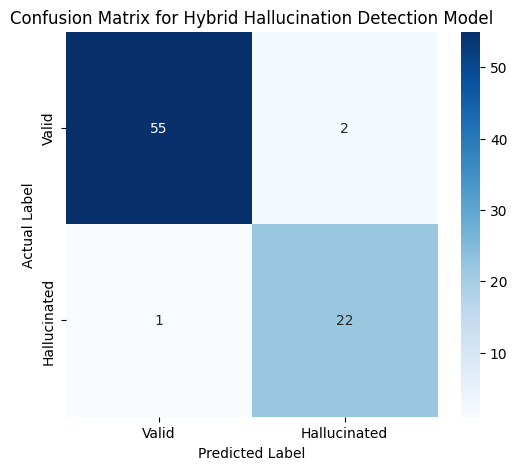

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Valid", "Hallucinated"],
            yticklabels=["Valid", "Hallucinated"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix for Hybrid Hallucination Detection Model")

plt.savefig('confusion_matrix.png')

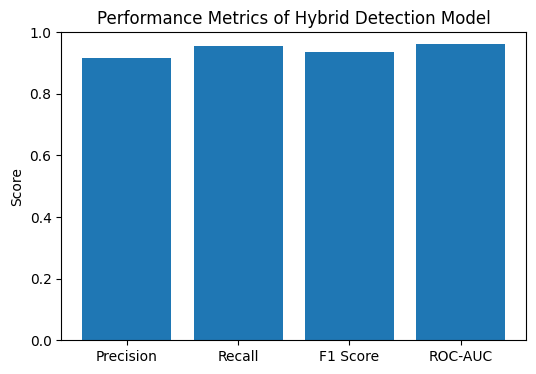

In [ ]:
metrics = {
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "ROC-AUC": roc_auc
}

plt.figure(figsize=(6,4))
plt.bar(metrics.keys(), metrics.values())

plt.ylim(0,1)
plt.title("Performance Metrics of Hybrid Detection Model")
plt.ylabel("Score")

plt.savefig('performance_matrix.png')

## Ablation Study

In [ ]:
signals = {
    "Signal_OpenAlex": df["Signal_OpenAlex"],
    "Signal_Title": df["Signal_Title"],
    "Hybrid_Score": df["Predicted_Hallucination"]
}

ablation_results = []

for name, pred in signals.items():
    if name == "Hybrid_Score":  # already thresholded
        y_pred = pred
    else:
        y_pred = pred  # already 0/1
    y_true = df["Ground_Truth"]
    ablation_results.append({
        "Signal": name,
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_pred)
    })

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df)

            Signal  Precision    Recall       F1   ROC-AUC
0  Signal_OpenAlex   0.916667  0.956522  0.93617  0.960717
1     Signal_Title   0.518519  0.608696  0.56000  0.690313
2     Hybrid_Score   0.916667  0.956522  0.93617  0.960717


In [ ]:
display(ablation_df)

,Signal,Precision,Recall,F1,ROC-AUC
0,Signal_OpenAlex,0.916667,0.956522,0.93617,0.960717
1,Signal_Title,0.518519,0.608696,0.56000,0.690313
2,Hybrid_Score,0.916667,0.956522,0.93617,0.960717


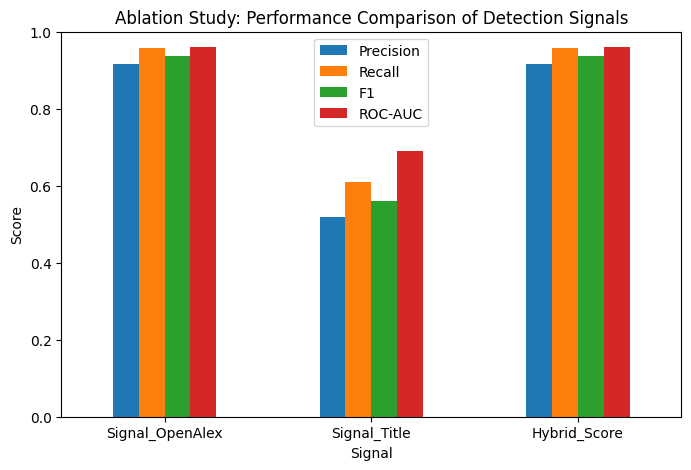

In [ ]:
ablation_df.set_index("Signal")[["Precision","Recall","F1","ROC-AUC"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylim(0,1)
plt.title("Ablation Study: Performance Comparison of Detection Signals")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.savefig('ablation_study.png')

## Error Analaysis

In [ ]:
false_positives = df[(df["Predicted_Hallucination"] == 1) & (df["Ground_Truth"] == 0)]
false_negatives = df[(df["Predicted_Hallucination"] == 0) & (df["Ground_Truth"] == 1)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))

# Examples
display(false_positives[["Input_Prompt", "Extracted_Title", "Paper_Title_Verified"]].head(10))
display(false_negatives[["Input_Prompt", "Extracted_Title", "Paper_Title_Verified"]].head(10))

False Positives: 2
False Negatives: 1


,Input_Prompt,Extracted_Title,Paper_Title_Verified
7,"What is the DOI for the ""PRISMA 2020 statement"" published in the BMJ?",PRISMA 2020 statement — PRISMA statement,PRISMA 2020 statement paper
58,"Cite the paper 'Cryo-EM Elucidates the Interaction Mechanism of Ozoralizumab, a Humanized Anti-TNFα NANOBODY® Compound' and provide its DOI. It was authored by Maima et al","Cryo-EM Elucidates the Interaction Mechanism of Ozoralizumab, a Humanized Anti-TNFα NANOBODY® Compound","Cryo-EM Elucidates the Interaction Mechanism of Ozoralizumab, a Humanized Anti-TNFα NANOBODY® Compound"


,Input_Prompt,Extracted_Title,Paper_Title_Verified
41,"What is the official DOI and publication venue for the study ""3D Deep Learning on Medical Images: A Review""? Also, summarize its key findings.",Deep‑Emotion: Facial Expression Recognition Using Attentional Convolutional Network,3D Deep Learning on Medical Images: A Review
